<div style="text-align: center; padding: 10px; background-color: #1e1e1e; color: white;">
   <img src="addthis1200x630.PNG" 
        width="400px" 
        alt="Logo Konrad Lorenz"
        style="margin: 15px auto; display: block;"/>
   <h3 style="margin-top: 10px; color: white;">Fundación Universitaria Konrad Lorenz </h3>
   <hr style="width: 60%; margin: 10px auto; border-color: #555;">
   <div style="font-size: 14px; line-height: 1.5;">
       <p><b>Proyecto:</b> Modelo de regresión lineal Completo</p>
       <p><b>Autor:</b> Carlos Daniel Amortegui Ferrer</p>
       <p><b>Facultad:</b> Maestría & Especialización en Analítica Estratégica de Datos</p>
       <p><b>Asignatura:</b> Machine Learning Probabilístico</p>
       <p><b>Correo:</b> carlosd.amorteguif@konradlorenz.edu.co </p>
       <p><b>Fecha:</b> 03/02/2025</p>
   </div>
   <hr style="width: 60%; margin: 10px auto; border-color: #555;">
</div>

In [6]:
# Regresión Lineal: Análisis de precios de casas de Saratoga
# Script educativo para clase de Machine Learning - Modelo Completo

# ===========================
# Importación de librerías
# ===========================

import pandas as pd  # Manejo de datos estructurados en DataFrames
import numpy as np  # Operaciones matemáticas y manejo de arreglos numéricos
import matplotlib.pyplot as plt  # Generación de gráficos y visualización de datos
import seaborn as sns  # Biblioteca de visualización avanzada basada en Matplotlib

# ===========================
# Librerías de Scikit-Learn (Machine Learning)
# ===========================

from sklearn.model_selection import train_test_split  # División de datos en conjuntos de entrenamiento y prueba
from sklearn.linear_model import LinearRegression  # Modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error  
# Métricas para evaluar el rendimiento del modelo

from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Estandarización de datos y codificación de variables categóricas
from sklearn.compose import ColumnTransformer  # Aplicación de transformaciones a columnas específicas
from sklearn.pipeline import Pipeline  # Creación de pipelines para procesamiento y modelado

# ===========================
# Librerías de Statsmodels (Análisis estadístico)
# ===========================

import statsmodels.api as sm  # Modelado estadístico y regresión avanzada
import statsmodels.formula.api as smf  # Especificación de modelos usando fórmulas estilo R

from statsmodels.stats.outliers_influence import variance_inflation_factor  
# Cálculo del factor de inflación de varianza (VIF) para detectar multicolinealidad

from statsmodels.stats.diagnostic import het_breuschpagan  
# Prueba de heterocedasticidad de Breusch-Pagan para evaluar la homocedasticidad del modelo

# ===========================
# Otras librerías estadísticas y de manejo de errores
# ===========================

import scipy.stats as stats  # Pruebas estadísticas y distribuciones de probabilidad
import warnings  # Control y filtrado de advertencias en la ejecución del código

In [7]:
# Configuramos visualizaciones y advertencias
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format  # Quitar notación científica

# Carga inicial de los datos

In [8]:
# 1. CARGA DE DATOS
print("="*80)
print("1. CARGA DE DATOS")
print("="*80)

df = pd.read_excel("Tabla_Total_Seleccionados.xlsx",
                   sheet_name="Variables_Seleccionadas")

df.head()

1. CARGA DE DATOS


,precio,metros_habitables,banyos,precio_terreno,Acres_totales,habitaciones,chimenea,categoria_antiguedad,aire_acondicionado,desague,calefaccion,consumo_calefacion
0,132500,906,1.00,50000,0.09,5,Tiene,Antigua,No,septic,electric,electric
1,181115,1953,2.50,22300,0.92,6,No tiene,Nueva,No,septic,hot water/steam,gas
2,109000,1944,1.00,7300,0.19,8,Tiene,Antigua,No,public/commercial,hot water/steam,gas
3,155000,1944,1.50,18700,0.41,5,Tiene,Media,No,septic,hot air,gas
4,86060,840,1.00,15000,0.11,3,No tiene,Nueva,Yes,public/commercial,hot air,gas


In [9]:
# Información básica del dataset
print("\nInformación del dataset:")
print(f"• Número de registros: {df.shape[0]}")
print(f"• Número de variables: {df.shape[1]}")


Información del dataset:
• Número de registros: 1728
• Número de variables: 12


# 2. EXPLORACIÓN Y PREPARACIÓN DE DATOS

In [10]:
print("\n" + "="*80)
print("2. EXPLORACIÓN Y PREPARACIÓN DE DATOS")
print("="*80)

# Identificamos tipos de variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {', '.join(num_cols)}")
print(f"Variables categóricas ({len(cat_cols)}): {', '.join(cat_cols)}")



2. EXPLORACIÓN Y PREPARACIÓN DE DATOS
Variables numéricas (6): precio, metros_habitables, banyos, precio_terreno, Acres_totales, habitaciones
Variables categóricas (6): chimenea, categoria_antiguedad, aire_acondicionado, desague, calefaccion, consumo_calefacion


### Estadísticas descriptivas para variables numéricas

In [11]:
# Estadísticas descriptivas para variables numéricas
print("\nEstadísticas descriptivas de variables numéricas:")
df[num_cols].describe().T



Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
precio,1728.00,211966.71,98441.39,5000.00,145000.00,189900.00,259000.00,775000.00
metros_habitables,1728.00,1754.98,619.94,616.00,1300.00,1634.50,2137.75,5228.00
banyos,1728.00,1.90,0.66,0.00,1.50,2.00,2.50,4.50
precio_terreno,1728.00,34557.19,35021.17,200.00,15100.00,25000.00,40200.00,412600.00
Acres_totales,1728.00,0.50,0.70,0.00,0.17,0.37,0.54,12.20
habitaciones,1728.00,7.04,2.32,2.00,5.00,7.00,8.25,12.00


### Frecuencias para variables categóricas

In [12]:
# Frecuencias para variables categóricas
print("\nFrecuencias de variables categóricas:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Frecuencias de variables categóricas:

chimenea:
chimenea
Tiene       57.2%
No tiene    42.8%
Name: proportion, dtype: str

categoria_antiguedad:
categoria_antiguedad
Media      48.7%
Antigua    30.3%
Nueva      21.0%
Name: proportion, dtype: str

aire_acondicionado:
aire_acondicionado
No     63.3%
Yes    36.7%
Name: proportion, dtype: str

desague:
desague
public/commercial    70.2%
septic               29.8%
Name: proportion, dtype: str

calefaccion:
calefaccion
hot air            64.9%
electric           17.7%
hot water/steam    17.5%
Name: proportion, dtype: str

consumo_calefacion:
consumo_calefacion
gas         69.3%
electric    18.2%
oil         12.5%
Name: proportion, dtype: str


### Verificamos valores nulos


In [13]:
# ===========================
# Manejo de valores nulos en un DataFrame
# ===========================

# Calcula la cantidad de valores nulos por columna
nulls = df.isnull().sum()

# Verifica si hay valores nulos en el DataFrame
if nulls.sum() > 0:
    print("\nValores nulos en el dataset:")
    # Muestra solo las columnas que tienen valores nulos
    print(nulls[nulls > 0])
    
    # Imputación de valores nulos
    print("\nImputando valores nulos...")
    
    # ===========================
    # Imputación en columnas numéricas
    # ===========================
    # Para cada columna numérica en `num_cols`, si tiene valores nulos, los reemplaza con la media de la columna
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mean())
    
    # ===========================
    # Imputación en columnas categóricas
    # ===========================
    # Para cada columna categórica en `cat_cols`, si tiene valores nulos, los reemplaza con la moda (valor más frecuente)
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
else:
    # Si no hay valores nulos en el dataset, imprime un mensaje de confirmación
    print("\n✓ No se encontraron valores nulos.")



✓ No se encontraron valores nulos.


# 3. VISUALIZACIÓN DE RELACIONES


3. VISUALIZACIÓN DE RELACIONES
✓ Matriz de correlación guardada como 'correlation_matrix.png'


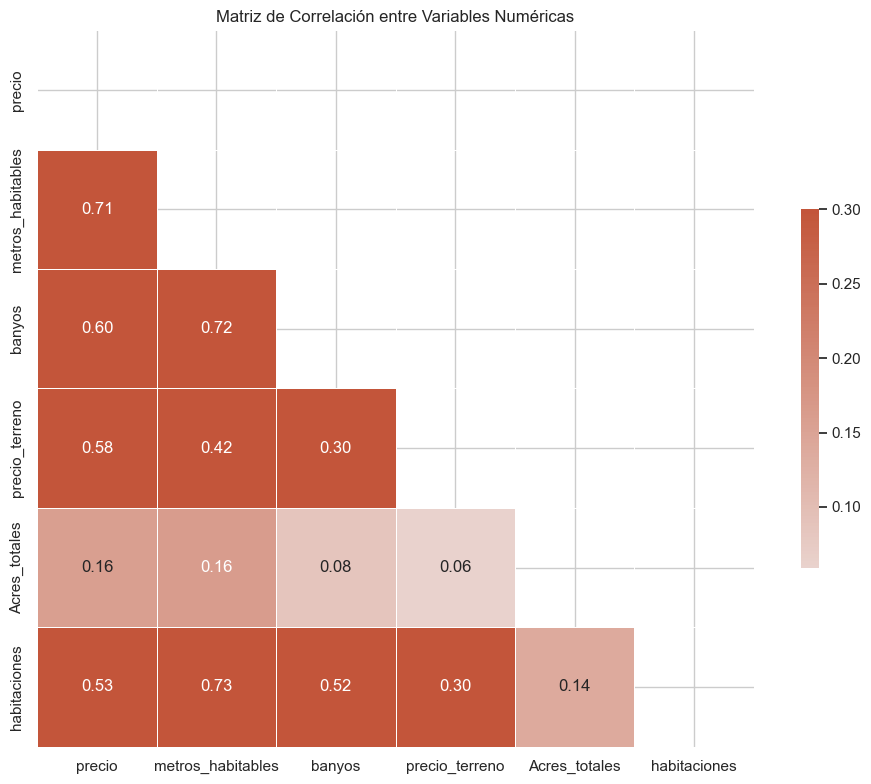

In [14]:
# 3. VISUALIZACIÓN DE RELACIONES
print("\n" + "="*80)
print("3. VISUALIZACIÓN DE RELACIONES")
print("="*80)

# Matriz de correlación para variables numéricas
plt.figure(figsize=(10, 8))
correlation = df[num_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(correlation, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.tight_layout()
# plt.savefig('correlation_matrix.png')
print("✓ Matriz de correlación guardada como 'correlation_matrix.png'")

In [15]:
# Correlación con la variable objetivo (precio)
print("\nCorrelación de variables numéricas con el precio:")
price_corr = correlation['precio'].sort_values(ascending=False)
print(price_corr)


Correlación de variables numéricas con el precio:
precio              1.00
metros_habitables   0.71
banyos              0.60
precio_terreno      0.58
habitaciones        0.53
Acres_totales       0.16
Name: precio, dtype: float64


✓ Boxplots de variables categóricas guardados como 'categorical_boxplots.png'


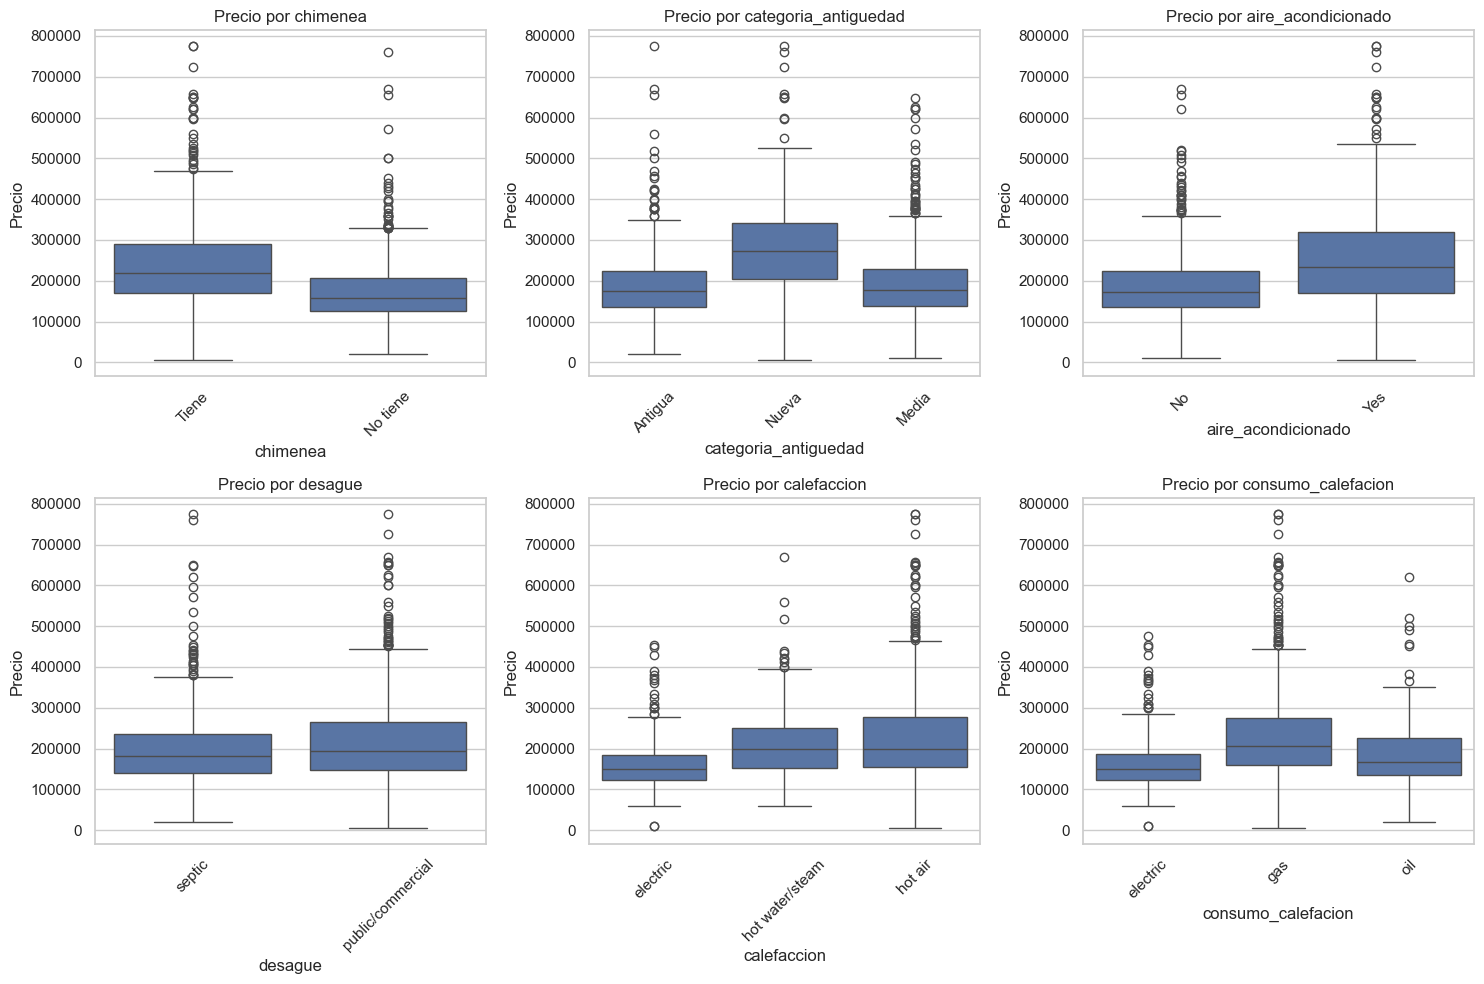

In [16]:
# Boxplots para variables categóricas vs precio
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, (len(cat_cols)+1)//2, i)
    sns.boxplot(x=col, y='precio', data=df)
    plt.title(f'Precio por {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('Precio')
plt.tight_layout()
# plt.savefig('categorical_boxplots.png')
print("✓ Boxplots de variables categóricas guardados como 'categorical_boxplots.png'")

# 4. PREPARACIÓN DEL MODELO

In [17]:
# 4. PREPARACIÓN DEL MODELO
# Imprime un separador y el título de la sección para organizar la salida en la consola
print("\n" + "="*80)
print("4. PREPARACIÓN DEL MODELO")
print("="*80)

# Definimos la variable objetivo: 'precio'
y = df['precio']

# Definimos las variables independientes: todas las columnas del DataFrame, excepto 'precio'
X = df.drop('precio', axis=1)

# Separamos los datos en conjuntos de entrenamiento y prueba
# test_size=0.2 indica que el 20% de los datos se reservará para prueba
# random_state=42 asegura la reproducibilidad de la separación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimimos la cantidad de registros en cada conjunto
# También se muestra el porcentaje que representa cada conjunto respecto al total
print(f"Datos divididos en:")
print(f"• Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X):.1%})")
print(f"• Prueba: {X_test.shape[0]} registros ({X_test.shape[0]/len(X):.1%})")


4. PREPARACIÓN DEL MODELO
Datos divididos en:
• Entrenamiento: 1382 registros (80.0%)
• Prueba: 346 registros (20.0%)


# 4.1 Procesado de variables y ajuste de modelo

In [18]:
# Crear un preprocesador que transforme las variables numéricas y categóricas:
# - Para las variables categóricas se utiliza OneHotEncoder para crear variables dummy.
#   drop='first' evita la trampa de la multicolinealidad eliminando una categoría.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)],
    remainder='passthrough')  # Mantiene las variables numéricas sin cambios

# Se crea un pipeline que integra el preprocesamiento y el ajuste del modelo
# - Primero se aplica el preprocesador definido anteriormente.
# - Luego, se ajusta un modelo de regresión lineal sobre los datos transformados.
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Mensaje para indicar el inicio del entrenamiento del modelo usando el pipeline
print("\nEntrenando modelo de regresión con pipeline...")

# Se entrena (ajusta) el pipeline sobre los datos de entrenamiento
pipe.fit(X_train, y_train)

# Mensaje de confirmación que indica que el modelo se entrenó correctamente
print("✓ Modelo entrenado correctamente")


Entrenando modelo de regresión con pipeline...
✓ Modelo entrenado correctamente


In [19]:
# ===========================
# Visualización de la tabla transformada
# ===========================

# Aplicar solo la transformación del preprocesador sin ajustar el modelo
X_train_transformed = pipe.named_steps['preprocessor'].transform(X_train)

# Obtener los nombres de las columnas transformadas de manera automática
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

# Convertir la salida transformada en un DataFrame con nombres de columnas correctos
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

# Mostrar las primeras filas de la tabla transformada
print("\nTabla transformada:")
X_train_transformed_df.head()  # Muestra solo las primeras filas para revisión



Tabla transformada:


,cat__chimenea_Tiene,cat__categoria_antiguedad_Media,cat__categoria_antiguedad_Nueva,cat__aire_acondicionado_Yes,cat__desague_septic,cat__calefaccion_hot air,cat__calefaccion_hot water/steam,cat__consumo_calefacion_gas,cat__consumo_calefacion_oil,remainder__metros_habitables,remainder__banyos,remainder__precio_terreno,remainder__Acres_totales,remainder__habitaciones
0,0.00,0.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00,2194.00,2.50,3500.00,1.00,8.00
1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,908.00,1.00,15700.00,0.15,3.00
2,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,2112.00,1.50,34700.00,0.54,9.00
3,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1435.00,1.50,61200.00,0.23,8.00
4,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1272.00,1.50,48200.00,0.23,8.00


# 5. EVALUACIÓN DEL MODELO

In [20]:
# 5. EVALUACIÓN DEL MODELO
print("\n" + "="*80)
print("5. EVALUACIÓN DEL MODELO")
print("="*80)

# Predicciones
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

# Métricas de evaluación
metrics = pd.DataFrame(index=['R²', 'R² ajustado', 'RMSE', 'MAE', 'MAPE (%)'])

# Entrenamiento
train_r2 = r2_score(y_train, y_pred_train)
train_adj_r2 = 1 - (1 - train_r2) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mape = mean_absolute_percentage_error(y_train, y_pred_train) * 100

# Prueba
test_r2 = r2_score(y_test, y_pred_test)
test_adj_r2 = 1 - (1 - test_r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

# Organizamos métricas
metrics['Entrenamiento'] = [train_r2, train_adj_r2, train_rmse, train_mae, train_mape]
metrics['Prueba'] = [test_r2, test_adj_r2, test_rmse, test_mae, test_mape]

print("Métricas de evaluación:")
metrics.round(4)


5. EVALUACIÓN DEL MODELO
Métricas de evaluación:


,Entrenamiento,Prueba
R²,0.65,0.58
R² ajustado,0.64,0.57
RMSE,56893.69,69939.03
MAE,40684.50,46495.34
MAPE (%),26.33,22.32


# 6. ANÁLISIS ESTADÍSTICO DETALLADO

In [21]:
# 6. ANÁLISIS ESTADÍSTICO DETALLADO
print("\n" + "="*80)
print("6. ANÁLISIS ESTADÍSTICO DETALLADO")
print("="*80)

# Enfoque utilizando formula de statsmodels
# Unir y_train con X_train para tener todos los datos en un solo DataFrame
train_data = pd.concat([y_train.reset_index(drop=True), 
                        X_train.reset_index(drop=True)], axis=1)

# Inspeccionamos los tipos de datos
print("Tipos de datos en el conjunto de entrenamiento:")
print(train_data.dtypes)

# Aseguramos que todos los datos sean numéricos o categóricos explícitos
for col in cat_cols:
    if col in train_data.columns:  # Aseguramos que la columna exista
        train_data[col] = train_data[col].astype('category')
        print(f"Convertida '{col}' a tipo categórico explícito")


6. ANÁLISIS ESTADÍSTICO DETALLADO
Tipos de datos en el conjunto de entrenamiento:
precio                    int64
metros_habitables         int64
banyos                  float64
precio_terreno            int64
Acres_totales           float64
habitaciones              int64
chimenea                    str
categoria_antiguedad        str
aire_acondicionado          str
desague                     str
calefaccion                 str
consumo_calefacion          str
dtype: object
Convertida 'chimenea' a tipo categórico explícito
Convertida 'categoria_antiguedad' a tipo categórico explícito
Convertida 'aire_acondicionado' a tipo categórico explícito
Convertida 'desague' a tipo categórico explícito
Convertida 'calefaccion' a tipo categórico explícito
Convertida 'consumo_calefacion' a tipo categórico explícito


In [22]:
# Construimos la fórmula para el modelo
cat_terms = [f"C({col})" for col in cat_cols if col in train_data.columns]
num_terms = [col for col in num_cols if col in train_data.columns and col != 'precio']
all_terms = num_terms + cat_terms

formula = 'precio ~ ' + ' + '.join(all_terms)
print(f"\nFórmula del modelo: {formula}")


Fórmula del modelo: precio ~ metros_habitables + banyos + precio_terreno + Acres_totales + habitaciones + C(chimenea) + C(categoria_antiguedad) + C(aire_acondicionado) + C(desague) + C(calefaccion) + C(consumo_calefacion)


In [23]:
# Ajustamos el modelo con la fórmula
try:
    model_formula = smf.ols(formula=formula, data=train_data).fit()
    print("\nModelo ajustado correctamente")
    print(model_formula.summary())
except Exception as e:
    print(f"\nError al ajustar el modelo: {e}")
    
    # Intento alternativo con menos variables
    print("\nIntentando con un modelo más simple...")
    reduced_formula = 'precio ~ ' + ' + '.join(num_terms)  # Solo variables numéricas
    model_formula = smf.ols(formula=reduced_formula, data=train_data).fit()
    print(model_formula.summary())


Modelo ajustado correctamente
                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     179.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          7.47e-297
Time:                        09:41:22   Log-Likelihood:                -17092.
No. Observations:                1382   AIC:                         3.421e+04
Df Residuals:                    1367   BIC:                         3.429e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

# Interpretación del Modelo de Regresión

## Calidad del modelo
- **R² = 0.647**: El modelo explica aproximadamente el 64.7% de la variabilidad en el precio de las casas
- **R² ajustado = 0.643**: Ajustando por el número de predictores, el modelo sigue explicando un 64.3%
- **F-estadístico = 179.0 (p < 0.001)**: El modelo en su conjunto es estadísticamente significativo

## Variables numéricas significativas
- **metros_habitables**: Por cada metro cuadrado adicional, el precio aumenta en $58.07 (p < 0.001)
- **banyos**: Cada baño adicional aumenta el precio en $22,670 (p < 0.001)
- **precio_terreno**: Por cada dólar adicional en el valor del terreno, el precio aumenta en $0.89 (p < 0.001)
- **Acres_totales**: Cada acre adicional aumenta el precio en $8,652.64 (p < 0.001)
- **habitaciones**: Cada habitación adicional aumenta el precio en $1,901.09, aunque es marginalmente significativo (p = 0.053)

## Variables categóricas significativas
- **Categoría de antigüedad**: Comparado con casas "Antiguas" (categoría base):
  - Casas "Nuevas" aumentan el precio en $21,490 (p < 0.001)
  - Casas "Medias" aumentan el precio en $10,730 (p = 0.011)
- **Aire acondicionado**: Tener aire acondicionado aumenta el precio en $9,919.65 (p = 0.009)

## Variables no significativas
- **Chimenea**: El efecto de tener chimenea no es estadísticamente significativo (p = 0.552)
- **Desagüe**: El tipo de desagüe no influye significativamente (p = 0.666)
- **Calefacción**: Ni el tipo ni el consumo de calefacción son significativos (p > 0.05)

## Diagnóstico del modelo
- **Multicolinealidad**: El número de condición es muy alto (8.64e+05), indicando posibles problemas de multicolinealidad entre las variables
- **Normalidad de residuos**: La prueba Omnibus (p < 0.001) y Jarque-Bera (p < 0.001) indican que los residuos no siguen una distribución normal
- **Asimetría y curtosis**: Los residuos muestran asimetría positiva (1.188) y son leptocúrticos (curtosis = 9.242), con colas más pesadas que la normal
- **Durbin-Watson = 1.962**: Valor cercano a 2 indica ausencia de autocorrelación en los residuos

## Conclusiones principales
1. Las características físicas (metros habitables, baños, acres) son los factores más influyentes en el precio
2. La antigüedad de la propiedad y la presencia de aire acondicionado son factores categóricos importantes
3. Los sistemas de calefacción y la presencia de chimenea no tienen un impacto significativo en el precio
4. El alto número de condición sugiere que algunas variables están correlacionadas, lo que podría afectar la estabilidad de los coeficientes estimados
5. La no normalidad de los residuos sugiere que podría ser necesario transformar la variable dependiente (precio) para mejorar el modelo



# Vamos por otro modelo

In [24]:
formula_mejorada = 'precio ~ metros_habitables + banyos + precio_terreno + Acres_totales + C(categoria_antiguedad) + C(aire_acondicionado) + C(chimenea)'
# Crear variable transformada
df['log_precio'] = np.log(df['precio'])
# Fórmula con transformación logarítmica
formula_log = 'log_precio ~ metros_habitables + banyos + precio_terreno + Acres_totales + C(categoria_antiguedad) + C(aire_acondicionado) + C(chimenea)'

In [25]:
# 1. Modelo mejorado con variables seleccionadas
modelo_mejorado = smf.ols(formula=formula_mejorada, data=train_data).fit()
print(modelo_mejorado.summary())

# 2. Modelo con transformación logarítmica
train_data['log_precio'] = np.log(train_data['precio'])
modelo_log = smf.ols(formula=formula_log, data=train_data).fit()
print(modelo_log.summary())

# 3. Comparación de rendimiento
y_pred_mejorado = modelo_mejorado.predict(train_data)
y_pred_log = np.exp(modelo_log.predict(train_data))  # Transformación inversa

# Calcular métricas para ambos modelos
metricas = pd.DataFrame(index=['R²', 'RMSE', 'MAE'])
metricas['Modelo Original'] = [0.647, 
                               np.sqrt(mean_squared_error(train_data['precio'], y_pred_train)),
                               mean_absolute_error(train_data['precio'], y_pred_train)]
metricas['Modelo Mejorado'] = [modelo_mejorado.rsquared,
                               np.sqrt(mean_squared_error(train_data['precio'], y_pred_mejorado)),
                               mean_absolute_error(train_data['precio'], y_pred_mejorado)]
metricas['Modelo Log'] = [modelo_log.rsquared,
                          np.sqrt(mean_squared_error(train_data['precio'], y_pred_log)),
                          mean_absolute_error(train_data['precio'], y_pred_log)]
metricas

                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     312.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.94e-302
Time:                        09:41:22   Log-Likelihood:                -17096.
No. Observations:                1382   AIC:                         3.421e+04
Df Residuals:                    1373   BIC:                         3.426e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

,Modelo Original,Modelo Mejorado,Modelo Log
R²,0.65,0.65,0.55
RMSE,56893.69,57050.33,63656.61
MAE,40684.50,40791.01,43404.03


# Conclusiones: Comparación de Modelos de Regresión Lineal

## Modelo Mejorado (sin transformación)

**Cambios realizados:**
- Eliminación de variables no significativas (habitaciones, desague, calefaccion, consumo_calefacion)
- Simplificación del modelo manteniendo solo las variables más relevantes

**Resultados:**
- **R² = 0.645** (reducción mínima respecto al 0.647 original)
- **R² ajustado = 0.643** (se mantiene igual que el modelo original)
- **F-estadístico = 312.0** (mejora significativa desde 179.0)
- **Número de condición = 1.89e+05** (reducción de multicolinealidad)

**Interpretación de coeficientes significativos:**
- **metros_habitables**: Cada metro cuadrado adicional aumenta el precio en $63.57
- **banyos**: Cada baño adicional aumenta el precio en $22,010
- **precio_terreno**: Cada dólar adicional en el valor del terreno aporta $0.89 al precio
- **Acres_totales**: Cada acre adicional aumenta el precio en $9,157
- **categoria_antiguedad[Nueva]**: Las casas nuevas cuestan $22,350 más que las antiguas
- **aire_acondicionado[Yes]**: El aire acondicionado añade $11,020 al precio de la propiedad

## Modelo con Transformación Logarítmica

**Enfoque:**
- Transformación logarítmica de la variable dependiente (log_precio)
- Mismas variables independientes que el modelo mejorado

**Resultados:**
- **R² = 0.552** (no comparable directamente con el modelo no transformado)
- **Mejor comportamiento estadístico** potencial
- **Interpretación en términos porcentuales**

**Interpretación de coeficientes:**
- **metros_habitables**: Cada metro adicional aumenta el precio aproximadamente un 0.03%
- **banyos**: Cada baño adicional aumenta el precio un 12.2%
- **categoria_antiguedad[Nueva]**: Las casas nuevas tienen precios 7.95% más altos
- **aire_acondicionado[Yes]**: El aire acondicionado aumenta el precio un 4.96%

## Comparación y Recomendaciones

**Ventajas del modelo sin transformación:**
1. Mayor R² y mejor ajuste general
2. Interpretación directa y sencilla de los coeficientes
3. Más adecuado para propósitos educativos y explicativos

**Ventajas del modelo logarítmico:**
1. Potencialmente mejor comportamiento estadístico de los residuos
2. Interpretación en términos porcentuales (útil para ciertos contextos)
3. Posiblemente más adecuado para predicciones en ciertos rangos de precios

**Recomendaciones para futuras mejoras:**
1. Considerar eliminar la variable `chimenea` (no significativa, p=0.605)
2. Explorar transformaciones intermedias (raíz cuadrada o Box-Cox)
3. Evaluar técnicas de regularización (Ridge o Lasso) para abordar la multicolinealidad
4. Investigar posibles interacciones entre variables (ej. metros_habitables × categoria_antiguedad)

## Conclusión Final

El proceso de modelado muestra la importancia del equilibrio entre la complejidad del modelo y su capacidad predictiva. Para fines educativos, el modelo mejorado sin transformación ofrece un buen balance entre interpretabilidad y precisión, aunque persisten algunos problemas estadísticos como la no normalidad de residuos y cierto grado de multicolinealidad.

Este ejercicio demuestra que la selección de modelos no consiste simplemente en maximizar métricas como R², sino en encontrar el modelo más parsimonioso que cumpla con los supuestos estadísticos y sea útil para el propósito específico del análisis.

# Modelo de Regresión Lineal Mejorado: Fórmula e Interpretación

## Fórmula del Modelo Mejorado

$$
\begin{align*}
Precio = &\beta_0 + \beta_1 \cdot \text{metros\_habitables} + \beta_2 \cdot \text{banyos} + \beta_3 \cdot \text{precio\_terreno} + \\
&\beta_4 \cdot \text{Acres\_totales} + \beta_5 \cdot \text{categoria\_antiguedad[Media]} + \\
&\beta_6 \cdot \text{categoria\_antiguedad[Nueva]} + \beta_7 \cdot \text{aire\_acondicionado[Yes]} + \\
&\beta_8 \cdot \text{chimenea[Tiene]} + \varepsilon
\end{align*}
$$

Donde:
- $\beta_0 = 8,314.75$ (Intercepto)
- $\beta_1 = 63.57$ (Coeficiente de metros_habitables)
- $\beta_2 = 22,010$ (Coeficiente de banyos)
- $\beta_3 = 0.89$ (Coeficiente de precio_terreno)
- $\beta_4 = 9,157.06$ (Coeficiente de Acres_totales)
- $\beta_5 = 9,033.57$ (Coeficiente de categoria_antiguedad[Media])
- $\beta_6 = 22,350$ (Coeficiente de categoria_antiguedad[Nueva])
- $\beta_7 = 11,020$ (Coeficiente de aire_acondicionado[Yes])
- $\beta_8 = 1,836.90$ (Coeficiente de chimenea[Tiene])
- $\varepsilon$ = Término de error

En notación de Python (statsmodels):
```python
formula = 'precio ~ metros_habitables + banyos + precio_terreno + Acres_totales + C(categoria_antiguedad) + C(aire_acondicionado) + C(chimenea)'
```

## Interpretación Detallada de los Parámetros

### 1. Intercepto: $\beta_0 = 8,314.75$ (p=0.129)
- Representa el precio base estimado cuando todas las variables numéricas son cero y las categóricas están en su nivel de referencia
- No es estadísticamente significativo (p>0.05)
- Tiene poca interpretación práctica ya que es poco probable tener una casa con cero metros habitables, cero baños, etc.

### 2. metros_habitables: $\beta_1 = 63.57$ (p<0.001)
- **Interpretación**: Por cada metro cuadrado adicional de espacio habitable, el precio de la propiedad aumenta en $63.57, manteniendo constantes las demás variables
- Es altamente significativo
- **Ejemplo**: Una casa con 50m² más de espacio habitable tendría un precio aproximadamente $3,178.50 mayor ($63.57 × 50)

### 3. banyos: $\beta_2 = 22,010$ (p<0.001)
- **Interpretación**: Cada baño adicional aumenta el precio en $22,010, manteniendo constantes las demás variables
- Es altamente significativo
- **Ejemplo**: Una casa con un baño más costaría aproximadamente $22,010 más

### 4. precio_terreno: $\beta_3 = 0.89$ (p<0.001)
- **Interpretación**: Por cada dólar adicional en el valor del terreno, el precio de la propiedad aumenta en $0.89
- Es altamente significativo
- **Ejemplo**: Un aumento de $10,000 en el valor del terreno corresponde a un aumento de $8,900 en el precio de la propiedad

### 5. Acres_totales: $\beta_4 = 9,157.06$ (p<0.001)
- **Interpretación**: Cada acre adicional de terreno aumenta el precio en $9,157.06
- Es altamente significativo
- **Ejemplo**: Una propiedad con 2 acres más de terreno tendría un precio aproximadamente $18,314.12 mayor

### 6. categoria_antiguedad[Media]: $\beta_5 = 9,033.57$ (p=0.017)
- **Interpretación**: Las casas de antigüedad "Media" tienen un precio $9,033.57 mayor que las casas "Antiguas" (categoría de referencia)
- Es estadísticamente significativo
- **Ejemplo**: Entre dos casas idénticas, una de antigüedad media costaría aproximadamente $9,034 más que una antigua

### 7. categoria_antiguedad[Nueva]: $\beta_6 = 22,350$ (p<0.001)
- **Interpretación**: Las casas "Nuevas" tienen un precio $22,350 mayor que las casas "Antiguas" (categoría de referencia)
- Es altamente significativo
- **Ejemplo**: Entre dos casas idénticas, una nueva costaría aproximadamente $22,350 más que una antigua

### 8. aire_acondicionado[Yes]: $\beta_7 = 11,020$ (p=0.002)
- **Interpretación**: Las propiedades con aire acondicionado tienen un precio $11,020 mayor que las que no lo tienen
- Es estadísticamente significativo
- **Ejemplo**: La instalación de aire acondicionado en una propiedad podría aumentar su valor en aproximadamente $11,020

### 9. chimenea[Tiene]: $\beta_8 = 1,836.90$ (p=0.605)
- **Interpretación**: Las propiedades con chimenea tienen un precio $1,836.90 mayor que las que no la tienen
- No es estadísticamente significativo (p>0.05)
- **Ejemplo**: Tener chimenea no afecta significativamente el precio cuando se controlan las demás variables

## Aplicación Práctica del Modelo

### Estimación del precio de una propiedad:

Consideremos una casa con:
- 150 metros cuadrados habitables
- 2 baños
- Precio del terreno: $30,000
- 0.5 acres de terreno total
- Categoría de antigüedad: Nueva
- Con aire acondicionado
- Sin chimenea

**Cálculo del precio estimado:**
```
Precio = 8,314.75 + (63.57 × 150) + (22,010 × 2) + (0.89 × 30,000) + (9,157.06 × 0.5) + 22,350 + 11,020 + 0

Precio = 8,314.75 + 9,535.50 + 44,020 + 26,700 + 4,578.53 + 22,350 + 11,020

Precio = $126,518.78
```

Este modelo permite:
1. Estimar precios de propiedades basados en características observables
2. Identificar qué características aportan más valor 
3. Tomar decisiones informadas sobre mejoras potenciales a una propiedad

## Limitaciones de la Interpretación

1. Los efectos son válidos solo dentro del rango de datos observados
2. Persiste cierto grado de multicolinealidad (número de condición = 1.89e+05)
3. La relación entre las variables podría no ser perfectamente lineal en la realidad
4. Algunas interacciones importantes podrían no estar capturadas en el modelo

# Como Quitamos el intecepto ? 

In [26]:
# Modelo sin intercepto usando la notación de fórmula
formula_sin_intercepto = 'precio ~ 0 + metros_habitables + banyos + precio_terreno + Acres_totales + C(categoria_antiguedad) + C(aire_acondicionado) + C(chimenea)'

# El "0 +" al inicio de la fórmula indica que no se debe incluir un intercepto
modelo_sin_intercepto = smf.ols(formula=formula_sin_intercepto, data=train_data).fit()
modelo_sin_intercepto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 precio   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     312.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.94e-302
Time:                        09:41:23   Log-Likelihood:                -17096.
No. Observations:                1382   AIC:                         3.421e+04
Df Residuals:                    1373   BIC:                         3.426e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
C(categoria_antiguedad)[Antigua]  8314.7492   5476.078      1.518      0.129   -2427.636    1.91e+04
C(categoria_antiguedad)[Media]    1.735e+04   5583.608      3.107      0.002    6394.989    2.83e+04
C(categoria_antiguedad)[Nueva]    3.066e+04   7479.767      4.099      0.000     1.6e+04    4.53e+04
C(aire_acondicionado)[T.Yes]      1.102e+04   3579.084      3.078      0.002    3996.673     1.8e+04
C(chimenea)[T.Tiene]              1836.9048   3555.117      0.517      0.605   -5137.144    8810.953
metros_habitables                   63.5704      3.861     16.464      0.000      55.996      71.145
banyos                            2.201e+04   3645.970      6.037      0.000    1.49e+04    2.92e+04
precio_terreno                       0.8858      0.050     17.836      0.000       0.788       0.983
Acres_totales                     9157.0573   2146.637      4.266      0.000    4946.015    1.34e+04
==============================================================================
Omnibus:                      409.400   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2662.768
Skew:                           1.213   Prob(JB):                         0.00
Kurtosis:                       9.353   Cond. No.                     3.28e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.28e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

_____________________________________

# Eliminemos atípicos

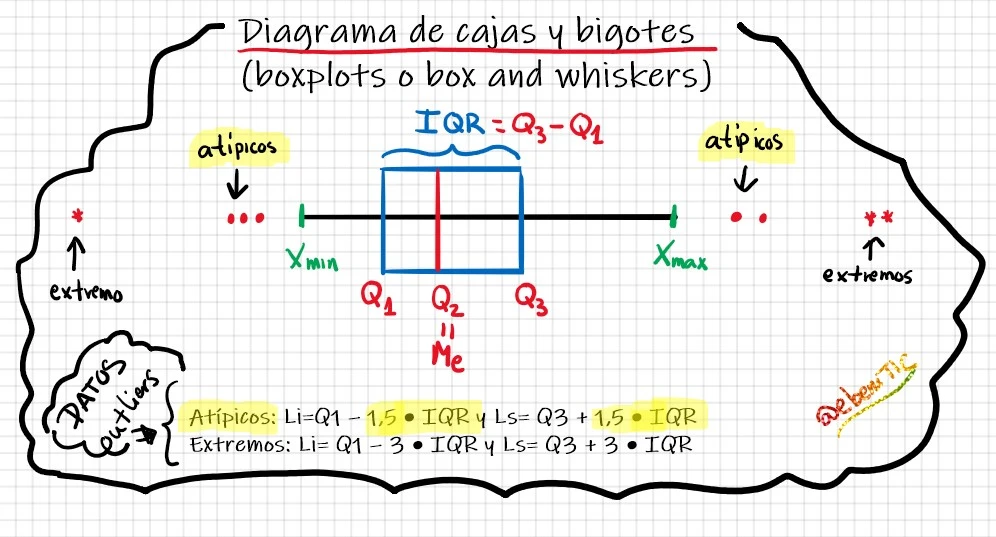

# 1. Identificación de outliers en la variable objetivo (precio)

In [27]:
# 1. Identificación de outliers en la variable objetivo (precio)
Q1 = train_data['precio'].quantile(0.25)
Q3 = train_data['precio'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para los outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límites para detectar outliers:")
print(f"Límite inferior: ${limite_inferior:.2f}")
print(f"Límite superior: ${limite_superior:.2f}")

Límites para detectar outliers:
Límite inferior: $-22756.25
Límite superior: $424593.75


In [28]:
# Identificar outliers
outliers = train_data[(train_data['precio'] < limite_inferior) | 
                      (train_data['precio'] > limite_superior)]
                      
print(f"\nNúmero de outliers detectados: {len(outliers)} ({len(outliers)/len(train_data):.1%} del conjunto de entrenamiento)")


Número de outliers detectados: 43 (3.1% del conjunto de entrenamiento)


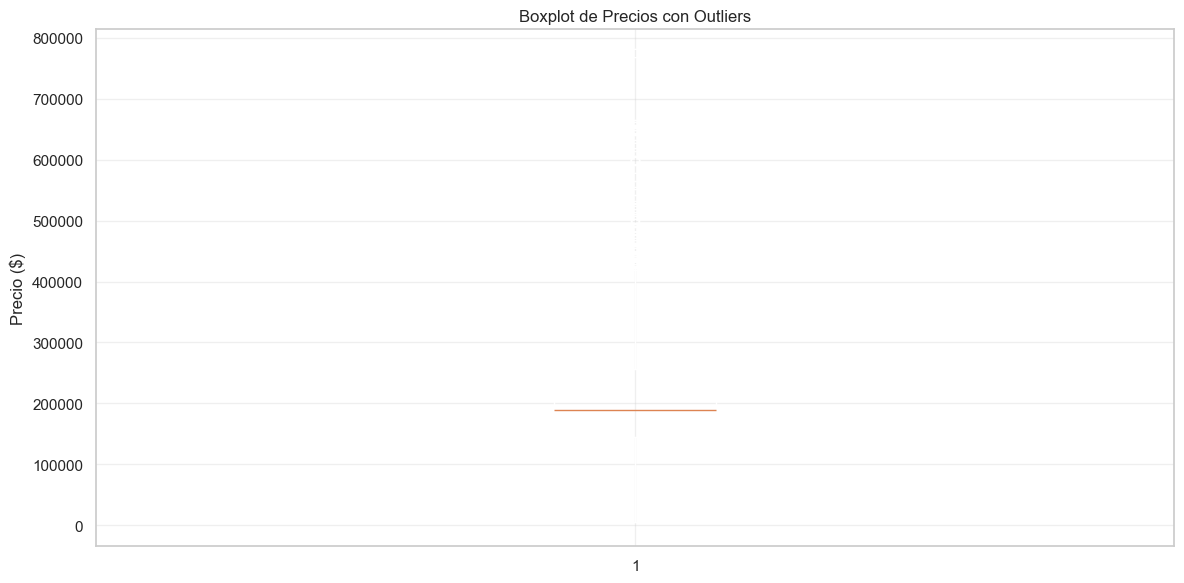

In [29]:

# Visualizar outliers
plt.figure(figsize=(12, 6))
plt.boxplot(train_data['precio'])
plt.title('Boxplot de Precios con Outliers')
plt.ylabel('Precio ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 2. Filtrar outliers

In [30]:
# 2. Filtrar outliers
train_data_sin_outliers = train_data[(train_data['precio'] >= limite_inferior) & 
                                     (train_data['precio'] <= limite_superior)]

print(f"\nTamaño del conjunto de datos:")
print(f"Original: {len(train_data)} observaciones")
print(f"Sin outliers: {len(train_data_sin_outliers)} observaciones")
print(f"Reducción: {len(train_data) - len(train_data_sin_outliers)} observaciones ({(len(train_data) - len(train_data_sin_outliers))/len(train_data):.1%})")


Tamaño del conjunto de datos:
Original: 1382 observaciones
Sin outliers: 1339 observaciones
Reducción: 43 observaciones (3.1%)


# 3. Ajustar el modelo mejorado sin outliers

In [31]:
# 3. Ajustar el modelo mejorado sin outliers
formula_mejorada = 'precio ~ metros_habitables + banyos + precio_terreno + Acres_totales + C(categoria_antiguedad) + C(aire_acondicionado) + C(chimenea)'

modelo_sin_outliers = smf.ols(formula=formula_mejorada, data=train_data_sin_outliers).fit()
print("\nModelo ajustado sin outliers:")
modelo_sin_outliers.summary()


Modelo ajustado sin outliers:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 precio   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     275.1
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.26e-275
Time:                        09:41:24   Log-Likelihood:                -16337.
No. Observations:                1339   AIC:                         3.269e+04
Df Residuals:                    1330   BIC:                         3.274e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         2.465e+04   4898.022      5.033      0.000     1.5e+04    3.43e+04
C(categoria_antiguedad)[T.Media]  6846.9445   3235.712      2.116      0.035     499.289    1.32e+04
C(categoria_antiguedad)[T.Nueva]   2.32e+04   4250.405      5.458      0.000    1.49e+04    3.15e+04
C(aire_acondicionado)[T.Yes]      9760.3040   3061.536      3.188      0.001    3754.337    1.58e+04
C(chimenea)[T.Tiene]              4067.3164   3038.514      1.339      0.181   -1893.486       1e+04
metros_habitables                   56.1435      3.469     16.183      0.000      49.338      62.950
banyos                            2.105e+04   3162.797      6.656      0.000    1.48e+04    2.73e+04
precio_terreno                       0.6972      0.048     14.397      0.000       0.602       0.792
Acres_totales                     9016.8066   2044.612      4.410      0.000    5005.790     1.3e+04
==============================================================================
Omnibus:                       74.514   Durbin-Watson:                   1.897
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              154.427
Skew:                           0.362   Prob(JB):                     2.93e-34
Kurtosis:                       4.497   Cond. No.                     1.76e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.76e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""